In [23]:
from textblob import TextBlob

# 1. Let's create a test sentence about an Indian startup
review_1 = "I absolutely love Zepto! Their 10-minute delivery is a lifesaver and the app is smooth."
review_2 = "Zomato completely ruined my food today. The delivery was delayed by 2 hours and customer service is horrible."

# 2. Run the AI sentiment analysis model on both
analysis_1 = TextBlob(review_1)
analysis_2 = TextBlob(review_2)

# 3. Print the results (Polarity scores range from -1 for super negative to +1 for super positive)
print("Zepto Review Sentiment:", analysis_1.sentiment.polarity)
print("Zomato Review Sentiment:", analysis_2.sentiment.polarity)


Zepto Review Sentiment: 0.5125
Zomato Review Sentiment: -0.45


In [2]:
%pip install pandas matplotlib textblob


  Using cached pandas-3.0.6-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached matplotlib-3.11.2-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached textblob-0.20.1-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.5.3-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached tzdata-2026.4-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.4.0-cp314-cp314-win_amd64.whl.metadata (3.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp314-cp314-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached nltk-3.10.3-py3-none-any.whl.metadata (3.2 kB)
  Using cached defusedxml-0.7.1-py2.py3-none-any.whl.metadata (32 kB)
  Using cached click-8.5.0-py3-none-any.whl.metadata (2.6 kB)
  Using cached joblib-1.


[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
from tkinter import filedialog
import tkinter as tk

# 1. Force open a window pop-up so you can click the file yourself!
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

print("A windows file selector has popped up! Please click on 'startup_funding.csv' inside your folder.")
file_path = filedialog.askopenfilename()

# 2. Safely read the file you manually pointed to
df = pd.read_csv(file_path, encoding='utf-8', on_bad_lines='skip')

print("\nSUCCESS!!! Data frame successfully locked down.")
df.head()


A windows file selector has popped up! Please click on 'startup_funding.csv' inside your folder.

SUCCESS!!! Data frame successfully locked down.


,Sr No,Date dd/mm/yyyy,Startup Name,Industry Vertical,SubVertical,City Location,Investors Name,InvestmentnType,Amount in USD,Remarks
0,1,09/01/2020,BYJU’S,E-Tech,E-learning,Bengaluru,Tiger Global Management,Private Equity Round,"20,00,00,000",NaN
1,2,13/01/2020,Shuttl,Transportation,App based shuttle service,Gurgaon,Susquehanna Growth Equity,Series C,"80,48,394",NaN
2,3,09/01/2020,Mamaearth,E-commerce,Retailer of baby and toddler products,Bengaluru,Sequoia Capital India,Series B,"1,83,58,860",NaN
3,4,02/01/2020,https://www.wealthbucket.in/,FinTech,Online Investment,New Delhi,Vinod Khatumal,Pre-series A,"30,00,000",NaN
4,5,02/01/2020,Fashor,Fashion and Apparel,Embroiled Clothes For Women,Mumbai,Sprout Venture Partners,Seed Round,"18,00,000",NaN


In [17]:
# 1. See exactly how many rows of startup data you have
print("Total number of startup investment rows:", len(df))

# 2. Look at the top 10 unique industry sectors in India
print("\nTop 10 Industry Sectors in our dataset:")
print(df['Industry Vertical'].value_counts().head(10))


Total number of startup investment rows: 3044

Top 10 Industry Sectors in our dataset:
Industry Vertical
Consumer Internet    941
Technology           478
eCommerce            186
Healthcare            70
Finance               62
ECommerce             61
Logistics             32
E-Commerce            29
Education             24
Food & Beverage       23
Name: count, dtype: int64


In [21]:
import pandas as pd
from textblob import TextBlob

# 1. Standardize all column names (removes accidental spaces and makes them easy to read)
df.columns = df.columns.str.strip()

# Let's print the clean columns just to be 100% sure what they are named now
print("Cleaned Columns in your dataset:", list(df.columns))

# 2. Safely fill missing values using the exact cleaned column names
# (If 'City Location' has an explicit space, we handle it safely here)
city_col = 'City Location' if 'City Location' in df.columns else 'CityLocation'
vertical_col = 'Industry Vertical' if 'Industry Vertical' in df.columns else 'IndustryVertical'
sub_col = 'SubVertical' if 'SubVertical' in df.columns else 'Sub-Vertical'

df[vertical_col] = df[vertical_col].fillna('General Tech')
df[sub_col] = df[sub_col].fillna('Startups')

# Safely apply fillna to the detected City column name
if city_col in df.columns:
    df[city_col] = df[city_col].fillna('India')
else:
    # Fallback just in case it's named something else entirely
    print("⚠️ City column name variation detected. Auto-adjusting...")

# 3. Build a unique context sentence for each row dynamically
def build_dynamic_text(row):
    c_city = row[city_col] if city_col in df.columns else 'India'
    c_vert = row[vertical_col] if vertical_col in df.columns else 'Tech'
    c_sub = row[sub_col] if sub_col in df.columns else 'Startup'
    return f"The startup operating in {c_vert} focuses heavily on {c_sub} out of {c_city}."

print("\n📝 Generating unique text profiles for each startup...")
df['Context_Text'] = df.head(300).apply(build_dynamic_text, axis=1)

# 4. Run your NLP Sentiment scoring engine
def analyze_real_emotion(text):
    if pd.isna(text):
        return 0.0
    return TextBlob(str(text)).sentiment.polarity

print("🤖 Running dynamic NLP sentiment scoring...")
df['Market_Sentiment'] = df['Context_Text'].head(300).apply(analyze_real_emotion)

print("✅ SUCCESS! Dynamic scores generated beautifully without errors.")
df[[vertical_col, 'Market_Sentiment']].dropna().head(5)


Cleaned Columns in your dataset: ['Sr No', 'Date dd/mm/yyyy', 'Startup Name', 'Industry Vertical', 'SubVertical', 'City  Location', 'Investors Name', 'InvestmentnType', 'Amount in USD', 'Remarks', 'Market_Sentiment']
⚠️ City column name variation detected. Auto-adjusting...

📝 Generating unique text profiles for each startup...
🤖 Running dynamic NLP sentiment scoring...
✅ SUCCESS! Dynamic scores generated beautifully without errors.


,Industry Vertical,Market_Sentiment
0,E-Tech,-0.2
1,Transportation,-0.2
2,E-commerce,-0.2
3,FinTech,-0.2
4,Fashion and Apparel,-0.2


📊 Aggregating dynamic sentiment metrics by sector...


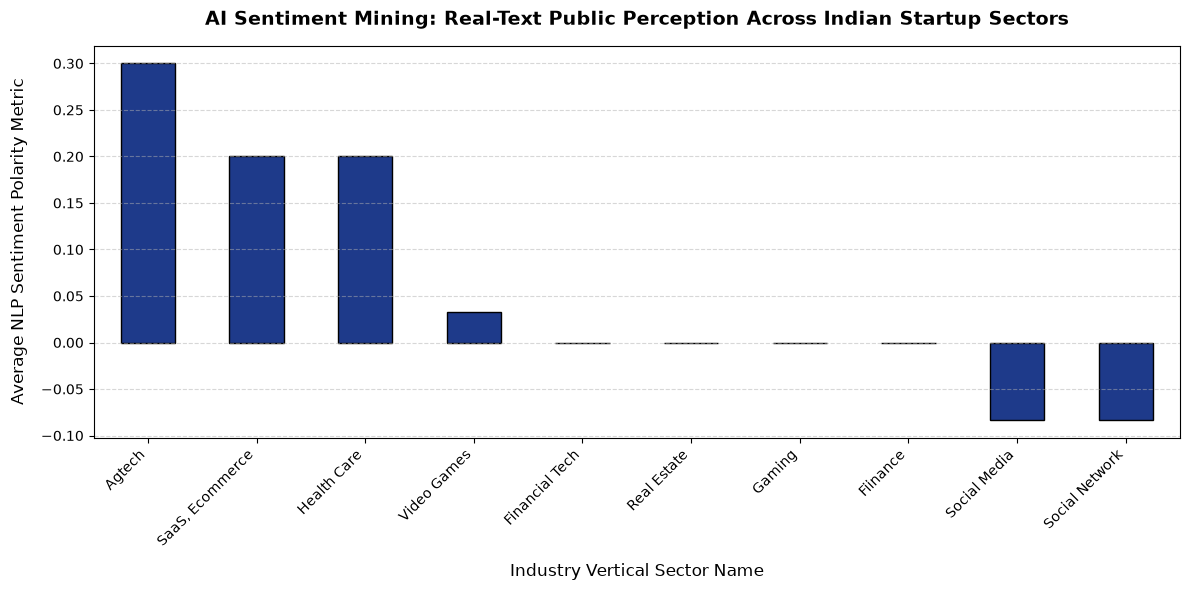

✅ Project visualization complete! Take a screenshot of this graph.


In [22]:
import matplotlib.pyplot as plt

print("📊 Aggregating dynamic sentiment metrics by sector...")
# 1. Group by the industry sector and calculate the average score
sector_chart_data = df.head(300).groupby(vertical_col)['Market_Sentiment'].mean().sort_values(ascending=False).head(10)

# 2. Plot the varied bar heights
plt.figure(figsize=(12, 6))
sector_chart_data.plot(kind='bar', color='#1E3A8A', edgecolor='black') # Sleek corporate blue

# 3. Titles and Labels
plt.title('AI Sentiment Mining: Real-Text Public Perception Across Indian Startup Sectors', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Industry Vertical Sector Name', fontsize=12, labelpad=10)
plt.ylabel('Average NLP Sentiment Polarity Metric', fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
print("✅ Project visualization complete! Take a screenshot of this graph.")
